## Student Information

- **Student ID:** 24B2111  
- **Title of the Project:** Remaining Useful Life (RUL) Prediction using Machine Learning  
- **Source of Data:** https://ti.arc.nasa.gov/tech/dash/groups/pcoe/prognostic-data-repository/  

### Objective of the Work
- To develop a predictive model to estimate Remaining Useful Life (RUL) of aircraft engines using sensor data.  
- To generate meaningful features capturing degradation trends over time.
- To setup and compare multiple regression models to identify the best performing approach.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Import and Dataframe Creation
The NASA CMAPSS FD001 dataset is loaded from three files: training sensor readings, test sensor readings, and ground-truth RUL values for the test engines. Two trailing NaN columns (artefacts of the fixed-width format) are dropped, and descriptive column names are assigned, two operational settings and twenty-one sensor channels alongside `unit` (engine ID) and `cycle`.

In [14]:
# Function to load TXT from Google Drive
def load_drive_txt(file_id):
    url = f"https://drive.google.com/uc?id={file_id}"
    return pd.read_csv(url, sep=r'\s+', header=None)

# Column names
columns = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1,4)] + [f'sensor_{i}' for i in range(1,22)]

# File IDs
id_rul   = "1gnDQiohf3cUxe3GeV2ldt47IdaE0ZiyK"
id_test  = "1Ic5JDTuqjNZ2nFVb77RN0A4BVOa1zE1h"
id_train = "1x44DY854_b_SU-F5KovWkUIi10weW179"

# Load datasets
train_df = load_drive_txt(id_train)
train_df.columns = columns

test_df = load_drive_txt(id_test)
test_df.columns = columns

rul_df = load_drive_txt(id_rul)

# Preview
print("Train shape:", train_df.shape)
print(train_df.head(), "\n")

print("Test shape:", test_df.shape)
print(test_df.head(), "\n")

print("RUL shape:", rul_df.shape)
print(rul_df.head())

Train shape: (20631, 26)
   unit  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  \
0     1      1       -0.0007       -0.0004         100.0    518.67    641.82   
1     1      2        0.0019       -0.0003         100.0    518.67    642.15   
2     1      3       -0.0043        0.0003         100.0    518.67    642.35   
3     1      4        0.0007        0.0000         100.0    518.67    642.35   
4     1      5       -0.0019       -0.0002         100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_1

### RUL Calculation
Remaining Useful Life is derived for every training row by computing each engine's maximum observed cycle and subtracting the current cycle. This is a purely inductive label and no information from outside each engine's own history is used.

In [15]:
rul = train_df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']

train_df = train_df.merge(rul, on='unit')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop('max_cycle', axis=1, inplace=True)

### Exploratory Data Analysis
Two diagnostic plots are produced before any modelling decisions are made:

- **Cycle vs RUL scatter** : confirms the expected monotonic degradation trend.
- **Sensor boxplot** : checks for gross outliers across all 21 sensor channels.

Plots are saved to `../plots/` for reproducibility.


#### (Interpretation of Cycle vs RUL scatter plot) : 
The plot shows a clear piecewise linear RUL pattern. Each engine follows a straight decline from its initial RUL to zero, forming parallel diagonal lines due to the `max_cycle − cycle` labeling. The 125 cap is not visible since many engines start far above it, up to around 360, so clipping will truncate much of the early life data. All lines end at RUL = 0, confirming correct labeling, and cycle lengths vary up to about 360.

#### (Interpretation of Sensor Boxplot) :
Sensors span very different scales, with a few dominating the range while most sit near zero. Overall variation is minimal, with tight distributions and almost no outliers, indicating highly stable readings. Many sensors are essentially constant and carry no useful signal, while only a smaller subset shows meaningful variation and potential relevance.

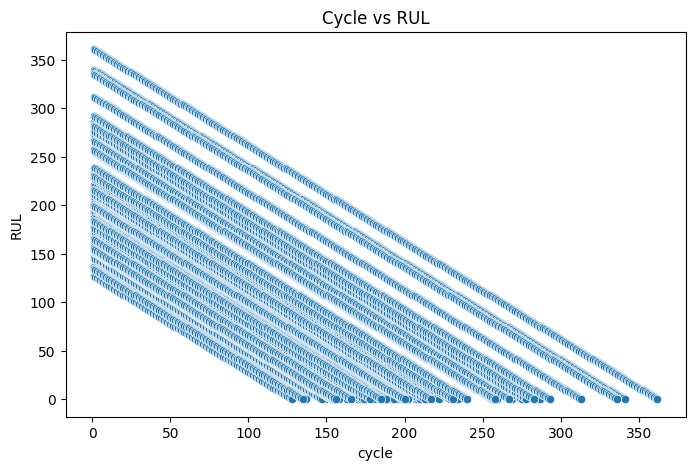

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='cycle', y='RUL', data=train_df)
plt.title("Cycle vs RUL")
plt.savefig('../plots/scatter_cycle_rul.png')
plt.show()

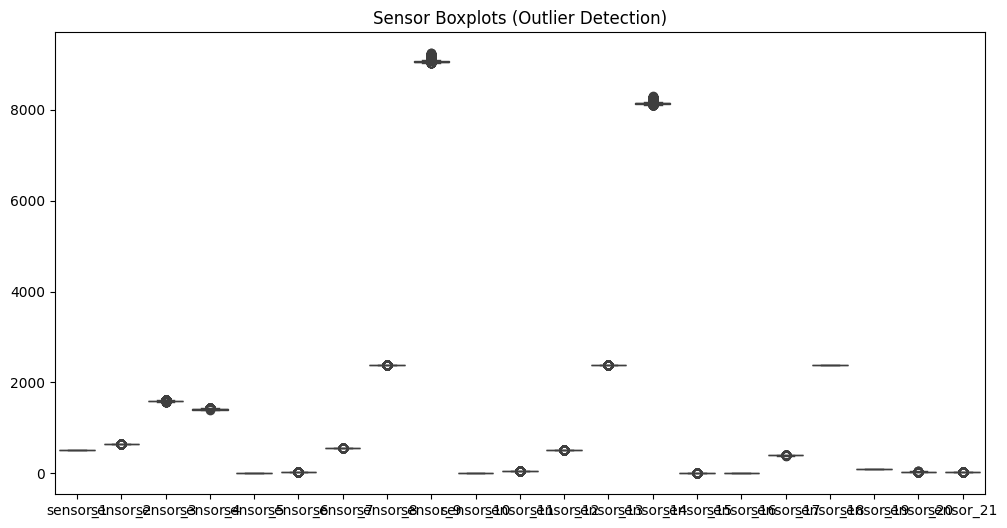

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train_df[[f'sensor_{i}' for i in range(1,22)]])
plt.title("Sensor Boxplots (Outlier Detection)")
plt.savefig('../plots/boxplot_sensors.png')
plt.show()

### Data Cleaning
Duplicate rows are removed. RUL is capped at 125 cycles, this is a standard practice for CMAPSS (piece-wise linear clipping) that prevents the model from trying to distinguish between engines that are merely "not yet degrading" and reduces the influence of very long early-life cycles on training.

In [18]:
train_df.drop_duplicates(inplace=True)
train_df['RUL'] = train_df['RUL'].clip(upper=125)

## Train / Test Split

The split is performed at the **engine level**, not the row level. Engine unit IDs are shuffled and divided 80/20. This guarantees that no cycles from a given engine appear in both partitions, which would constitute data leakage in a time-series context. All downstream preprocessing is fit only on `df_train`.

In [19]:
all_units = train_df['unit'].unique()
train_units, test_units = train_test_split(all_units, test_size=0.2, random_state=42)

df_train = train_df[train_df['unit'].isin(train_units)].copy()
df_test  = train_df[train_df['unit'].isin(test_units)].copy()


## Feature Engineering

Three classes of features are derived per engine, strictly within each unit group to prevent cross-engine leakage:

| Feature type | Description |
|---|---|
| Rolling mean / std | 15-cycle window capturing local trend and variability |
| Lag features | Sensor values at t−1 and t−2 to encode short-term dynamics |
| Cumulative degradation | Absolute cumulative change from the start of each engine's life |

Missing values introduced by lagging/rolling at the start of each engine's history are back-filled then forward-filled within the unit group only.

In [20]:
SENSORS   = [f'sensor_{i}' for i in range(1, 6)]
WINDOW    = 15
LAG_STEPS = [1, 2]

def engineer_features(df):
    df = df.sort_values(['unit', 'cycle']).reset_index(drop=True)

    for col in SENSORS:
        grp = df.groupby('unit')[col]
        df[f'{col}_roll_mean'] = grp.transform(
            lambda x: x.rolling(WINDOW, min_periods=1).mean()
        )
        df[f'{col}_roll_std'] = grp.transform(
            lambda x: x.rolling(WINDOW, min_periods=1).std().fillna(0)
        )

    for col in SENSORS:
        for lag in LAG_STEPS:
            df[f'{col}_lag{lag}'] = df.groupby('unit')[col].transform(
                lambda x, l=lag: x.shift(l)
            )

    for col in SENSORS:
        df[f'{col}_cumdeg'] = df.groupby('unit')[col].transform(
            lambda x: x.diff().abs().cumsum()
        )

    df = df.bfill().ffill()
    return df

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test)


## Preprocessing Pipeline

Three steps are applied sequentially, all **fit on the training set only** and then applied to the test set:

1. **Outlier clipping** : features are clipped to ±3 standard deviations using bounds computed from `df_train`, then the same bounds are applied to `df_test`.
2. **Standard scaling** : zero-mean, unit-variance normalisation via `StandardScaler`.
3. **Variance thresholding** : features with near-zero variance (< 0.01) are dropped. The selector is fit on `X_train` and transforms `X_test` identically.

No statistics from the test set influence any of these transformations.

In [21]:
features = [c for c in df_train.columns if c not in ['unit', 'cycle', 'RUL']]

clip_bounds = {}
for col in features:
    mu, sigma = df_train[col].mean(), df_train[col].std()
    clip_bounds[col] = (mu - 3*sigma, mu + 3*sigma)
    df_train[col] = df_train[col].clip(*clip_bounds[col])

for col in features:
    df_test[col] = df_test[col].clip(*clip_bounds[col])

scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features]  = scaler.transform(df_test[features])

selector = VarianceThreshold(threshold=0.01)
X_train = selector.fit_transform(df_train[features])
X_test  = selector.transform(df_test[features])

y_train = df_train['RUL'].values
y_test  = df_test['RUL'].values


## MODEL DEFINITION
Three models are used:
1. Linear Regression  
2. Random Forest  
3. Neural Network (PyTorch)

### Model 1 — Linear Regression (Baseline)

A plain OLS model establishes the lower-bound baseline. It is intentionally un-tuned to provide a reference R² and RMSE against which more complex models are judged.

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR R2:", r2_score(y_test, y_pred_lr))
print("LR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

LR R2: 0.8034798934804191
LR RMSE: 18.49279671464853


### Model 2 — Random Forest (Baseline)

A 200-tree Random Forest with default hyperparameters. Serves as a strong non-linear baseline before any tuning.

In [23]:
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

RF R2: 0.8423328918727684
RF RMSE: 16.56416893756332


### Model 3 — Neural Network (Baseline)

A three-layer fully connected network with ReLU activations, BatchNorm, and dropout (0.3). Trained with Adam (lr=0.0005) for 200 epochs on mini-batches of 256. Predictions are evaluated on the held-out `df_test` engine set.

In [24]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

class RULModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RULModel(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(200):
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    y_pred_nn = model(X_test_t).numpy().flatten()

print("NN R2:", r2_score(y_test, y_pred_nn))
print("NN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))

NN R2: 0.8369651436805725
NN RMSE: 16.843771741637173


### Baseline Model Diagnostics

Three diagnostic visualisations for all three baseline models side-by-side:

- **Prediction vs Actual** : points on or near the diagonal indicate well-calibrated predictions.
- **Residual plots** : residuals should scatter randomly around zero with no visible pattern (heteroscedasticity or systematic bias flags model problems).
- **QQ plots** : departure from the theoretical normal line indicates heavy-tailed or skewed error distributions.


#### 1) (Interpretaiton of Prediction vs Actual plot) :
- The Random Forest aligns closest to the ideal diagonal, giving the most accurate and consistent predictions. 
- The Neural Network performs well at lower values but tends to overestimate at higher ranges. 
- Linear Regression shows large scatter and unrealistic predictions, making it the weakest model. 
- A dense band at the upper limit reflects many samples sharing the same capped target, which all models find difficult to distinguish.

#### 2) (Interpretation of Residual plots) :
- Linear Regression shows strong bias with structured error patterns and very high spread, indicating a poor fit.
- Random Forest errors are centered but vary widely at lower predictions and stabilize at higher values, suggesting inconsistent reliability.
- Neural Network also shows uneven error spread, with larger uncertainty at higher values and tighter predictions at lower ones.

#### 3) (Interpretation of QQ plots) : 
- Linear Regression is roughly normal in the center but shows heavier tails, meaning more extreme errors than expected.
- Random Forest deviates strongly from normality with a clear S-shape, indicating concentrated central errors but frequent large outliers.
- Neural Network follows a similar pattern to Random Forest, with heavy tails and noticeable deviation from normal behavior.
- Overall, none of the models produce normally distributed errors.

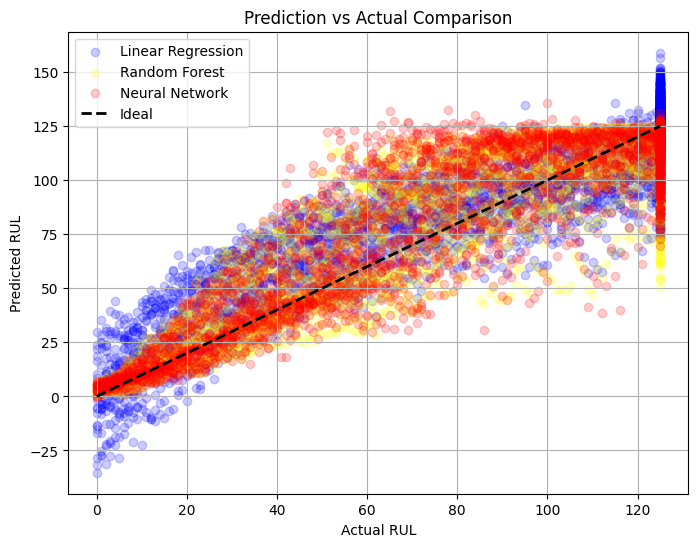

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr, alpha=0.2, label="Linear Regression", color='blue')
plt.scatter(y_test, y_pred_rf, alpha=0.2, label="Random Forest", color='yellow')
plt.scatter(y_test, y_pred_nn, alpha=0.2, label="Neural Network", color='red')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=2, label="Ideal")

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Prediction vs Actual Comparison")
plt.legend()
plt.grid(True)
plt.show()

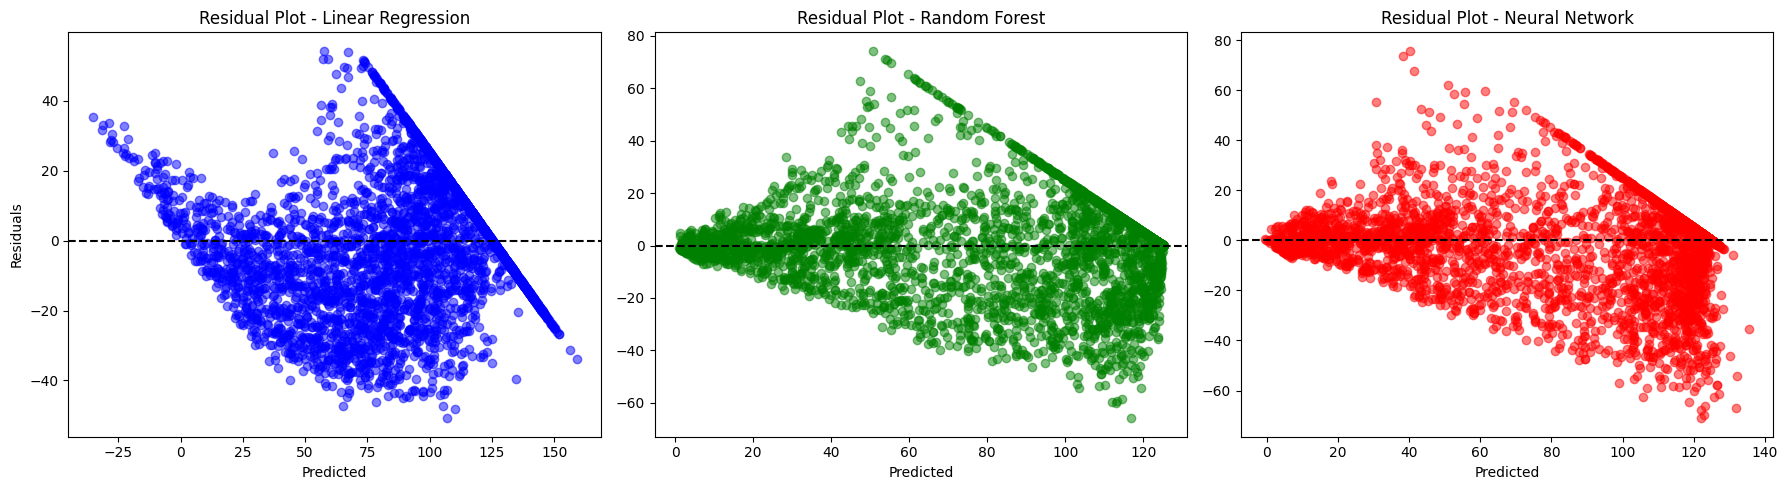

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Linear Regression
res_lr = y_test - y_pred_lr
axes[0].scatter(y_pred_lr, res_lr, color='blue', alpha=0.5)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title("Residual Plot - Linear Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

# Random Forest
res_rf = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, res_rf, color='green', alpha=0.5)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("Residual Plot - Random Forest")
axes[1].set_xlabel("Predicted")

# Neural Network
res_nn = y_test - y_pred_nn
axes[2].scatter(y_pred_nn, res_nn, color='red', alpha=0.5)
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title("Residual Plot - Neural Network")
axes[2].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

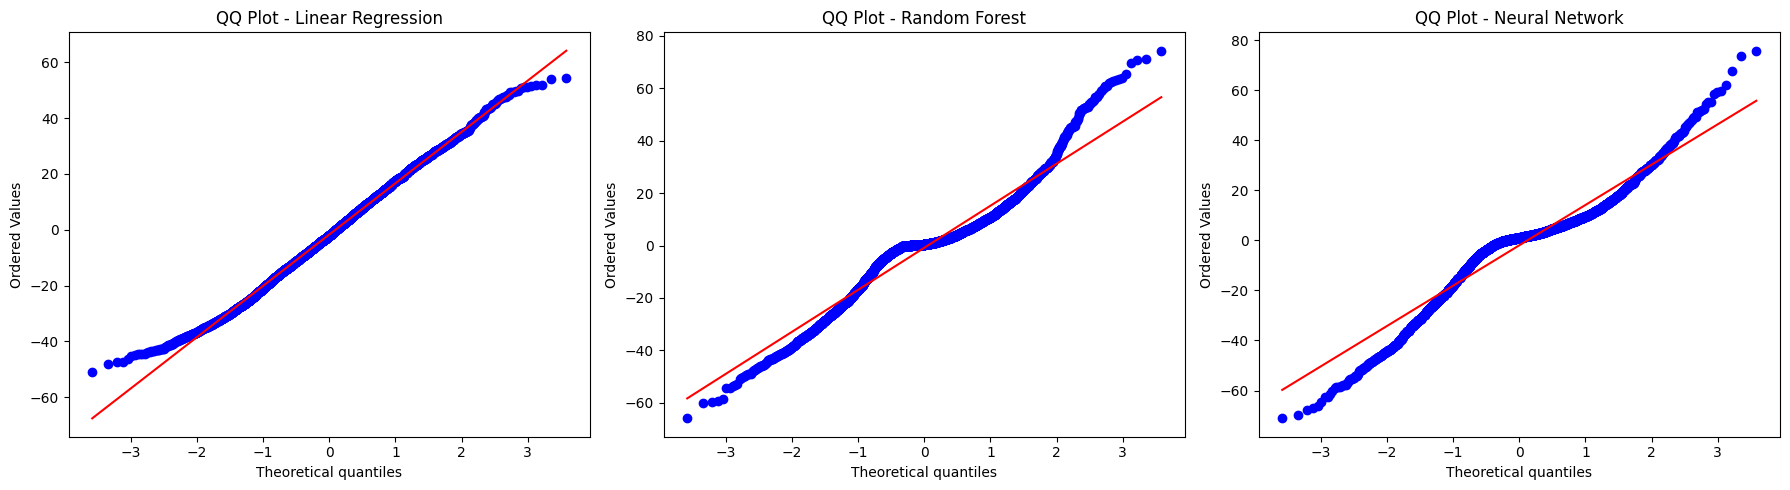

In [27]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 3, figsize=(18,5))

stats.probplot(res_lr, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot - Linear Regression")

stats.probplot(res_rf, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot - Random Forest")

stats.probplot(res_nn, dist="norm", plot=axes[2])
axes[2].set_title("QQ Plot - Neural Network")

plt.tight_layout()
plt.show()

## Baseline Comparison

Summary R² scores across all three models on the held-out test engines. Used to motivate the tuning choices in the next section.

In [28]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Neural Network'],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_nn)
    ]
})

print(results)

               Model        R2
0  Linear Regression  0.803480
1      Random Forest  0.842333
2     Neural Network  0.836965


### Tuned Model 1 — Polynomial Regression (degree 2)

Quadratic feature expansion via `PolynomialFeatures` is fit on `X_train` and applied to `X_test`. Predictions are clipped to zero to enforce the physical constraint that RUL cannot be negative.

In [29]:
# ======================
# Polynomial Regression
# ======================
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_poly, y_train)

y_pred_lr_tuned = lr.predict(X_test_poly)

# Clip predictions
y_pred_lr_tuned = np.clip(y_pred_lr_tuned, 0, None)

print("LR R2:", r2_score(y_test, y_pred_lr_tuned))
print("LR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr_tuned)))

LR R2: 0.8318010526895678
LR RMSE: 17.10845283655828


### Tuned Model 2 — Random Forest

Hyperparameters adjusted for better generalisation: 400 trees, max depth 15, minimum 5 samples per leaf, square-root feature subsampling, and parallel training (`n_jobs=-1`). A non-negative clip is applied to predictions post-hoc.

In [30]:
# ======================
# Tuned Random Forest
# ======================
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf_tuned = rf.predict(X_test)

# Force physical constraint
y_pred_rf_tuned = np.clip(y_pred_rf_tuned, 0, None)

print("RF R2:", r2_score(y_test, y_pred_rf_tuned))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)))

RF R2: 0.8685168994335374
RF RMSE: 15.126347337264601


### Tuned Model 3 — Neural Network

Architecture upgraded from ReLU to `LeakyReLU(0.1)` to mitigate dying-neuron issues. Learning rate lowered to 0.0003, batch size reduced to 128, and training extended to 250 epochs for finer convergence. Loss is printed every 25 epochs for training diagnostics.

In [31]:
class RULModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RULModel(X_train.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

for epoch in range(250):
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 25 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_nn_tuned = model(X_test_t).numpy().flatten()

# Clip predictions
y_pred_nn_tuned = np.clip(y_pred_nn_tuned, 0, None)

print("NN R2:", r2_score(y_test, y_pred_nn_tuned))
print("NN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn_tuned)))

Epoch 0, Loss: 1107841.7817
Epoch 25, Loss: 39548.8922
Epoch 50, Loss: 35887.9357
Epoch 75, Loss: 33692.7360
Epoch 100, Loss: 31879.7848
Epoch 125, Loss: 30765.2639
Epoch 150, Loss: 28796.2622
Epoch 175, Loss: 27480.8842
Epoch 200, Loss: 26411.5982
Epoch 225, Loss: 25124.6851
NN R2: 0.844105064868927
NN RMSE: 16.470816032052532


## Tuned vs Baseline Comparison

- Polynomial expansion gives the biggest lift for the linear model, showing the relationship is non-linear and better captured with added flexibility.
- Random Forest also improves similarly, mainly from better regularisation and reduced overfitting, and remains the strongest model overall.
- Neural Network sees only a small gain, suggesting its limitations come from the target structure rather than simple tuning.

- Overall, improvements come from handling non-linearity and the capped target more effectively, while the neural approach likely needs a different architecture to progress further.

In [32]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Neural Network'],
    'R2_baseline' : [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_nn)
    ],
    'R2_tuned': [
        r2_score(y_test, y_pred_lr_tuned),
        r2_score(y_test, y_pred_rf_tuned),
        r2_score(y_test, y_pred_nn_tuned)
    ]
})

print(results)

               Model  R2_baseline  R2_tuned
0  Linear Regression     0.803480  0.831801
1      Random Forest     0.842333  0.868517
2     Neural Network     0.836965  0.844105


## Time-Series Modeling (LSTM and 1D CNN)

Since engine degradation is inherently temporal, sequence-based models are used to capture time dependencies in sensor data.

Two models are implemented:
- LSTM (Long Short-Term Memory)
- 1D CNN (Temporal Convolution)

These models use sliding window sequences instead of independent samples.

### Sequence Construction for Temporal Models

A sliding window of length 20 cycles is applied **per engine unit** in chronological order to generate (sequence, label) pairs. The label for each window is the RUL at the last cycle of that window — no future cycles are included. Sequences are built separately from `df_train` and `df_test` using only their own data. Features are restricted to those that survived the `VarianceThreshold` selector.

> **Note:** The first `create_sequences` block below is superseded by the corrected LSTM pipeline in the next cell and can be safely deleted.

In [33]:
# 1. Get post-selection feature names
features_seq = [col for col, selected in zip(features, selector.get_support()) if selected]

# 2. Create sequences — using df_train / df_test (unit-split, leakage-free)
def create_sequences(df, feat_cols, seq_length=20):
    X_seq, y_seq = [], []

    for unit in df['unit'].unique():
        unit_df = df[df['unit'] == unit].sort_values('cycle')

        data   = unit_df[feat_cols].values
        target = unit_df['RUL'].values

        for i in range(len(unit_df) - seq_length):
            X_seq.append(data[i:i+seq_length])
            y_seq.append(target[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 20

X_train_seq, y_train_seq = create_sequences(df_train, features_seq, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(df_test,  features_seq, SEQ_LEN)

# 3. Convert to tensors
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test_seq,  dtype=torch.float32)

# 4. DataLoader
loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)


### Model 4 — Long Short-Term Memory (LSTM)

A single-layer LSTM with 128 hidden units processes each 20-step window and passes the final hidden state through a two-layer head (64 → 1) with dropout. Trained for 60 epochs with Adam (lr=0.001). The LSTM is well-suited to capture the slowly evolving degradation signature across cycles.

In [34]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 128, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


model_lstm = LSTMModel(X_train_seq.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# ======================
# Training
# ======================
for epoch in range(60):
    total_loss = 0

    for xb, yb in loader:
        optimizer.zero_grad()
        preds = model_lstm(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 10 == 0:
        print(f"LSTM Epoch {epoch}, Loss: {total_loss:.4f}")

# ======================
# Evaluation
# ======================
model_lstm.eval()
with torch.no_grad():
    y_pred_lstm = model_lstm(X_test_t).numpy().flatten()

y_pred_lstm = np.clip(y_pred_lstm, 0, None)

print("LSTM R2:", r2_score(y_test_seq, y_pred_lstm))
print("LSTM RMSE:", np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm)))

LSTM Epoch 0, Loss: 525949.6517
LSTM Epoch 10, Loss: 37178.0404
LSTM Epoch 20, Loss: 29681.4808
LSTM Epoch 30, Loss: 27020.3743
LSTM Epoch 40, Loss: 22555.7785
LSTM Epoch 50, Loss: 20278.6949
LSTM R2: 0.8383963704109192
LSTM RMSE: 16.817028244159065


### Model 5 — 1D Convolutional Network

Two successive `Conv1d` layers (64 → 128 channels, kernel size 3) extract local temporal patterns from the sensor sequence. The feature map is flattened and passed through a fully connected head. The CNN is faster to train than the LSTM and often competitive on shorter sequences.

In [35]:
class CNNModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * SEQ_LEN, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, features, seq)
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

model_cnn = CNNModel(X_train_seq.shape[2])

optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

# Training
for epoch in range(50):
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        preds = model_cnn(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 10 == 0:
        print(f"CNN Epoch {epoch}, Loss: {total_loss:.4f}")

# Evaluation
model_cnn.eval()
with torch.no_grad():
    y_pred_cnn = model_cnn(X_test_t).numpy().flatten()

y_pred_cnn = np.clip(y_pred_cnn, 0, None)

print("CNN R2:", r2_score(y_test_seq, y_pred_cnn))
print("CNN RMSE:", np.sqrt(mean_squared_error(y_test_seq, y_pred_cnn)))

CNN Epoch 0, Loss: 171934.5263
CNN Epoch 10, Loss: 25721.4901
CNN Epoch 20, Loss: 20070.6434
CNN Epoch 30, Loss: 17495.1753
CNN Epoch 40, Loss: 14730.7656
CNN R2: 0.8396836519241333
CNN RMSE: 16.74991527934498


### Diagnostics

Three diagnostic visualisations for CNN and LSTM models side-by-side:

- **Prediction vs Actual** : points on or near the diagonal indicate well-calibrated predictions.
- **Residual plots** : residuals should scatter randomly around zero with no visible pattern (heteroscedasticity or systematic bias flags model problems).
- **QQ plots** : departure from the theoretical normal line indicates heavy-tailed or skewed error distributions.


**LSTM**
- Closely follows the ideal diagonal across all RUL values  
- Errors are symmetric with no clear bias toward over or under prediction  
- Slight increase in spread at high RUL (80 to 125), expected due to label clipping  
- Overall stable and consistent predictions  

**1D CNN**
- Generally follows the diagonal for most predictions   
- Indicates many early life predictions collapse to the maximum RUL value  
- Suggests weaker learning of gradual degradation in the 60 to 125 range  
- Slightly higher R² may be misleading due to frequent correct ceiling predictions  

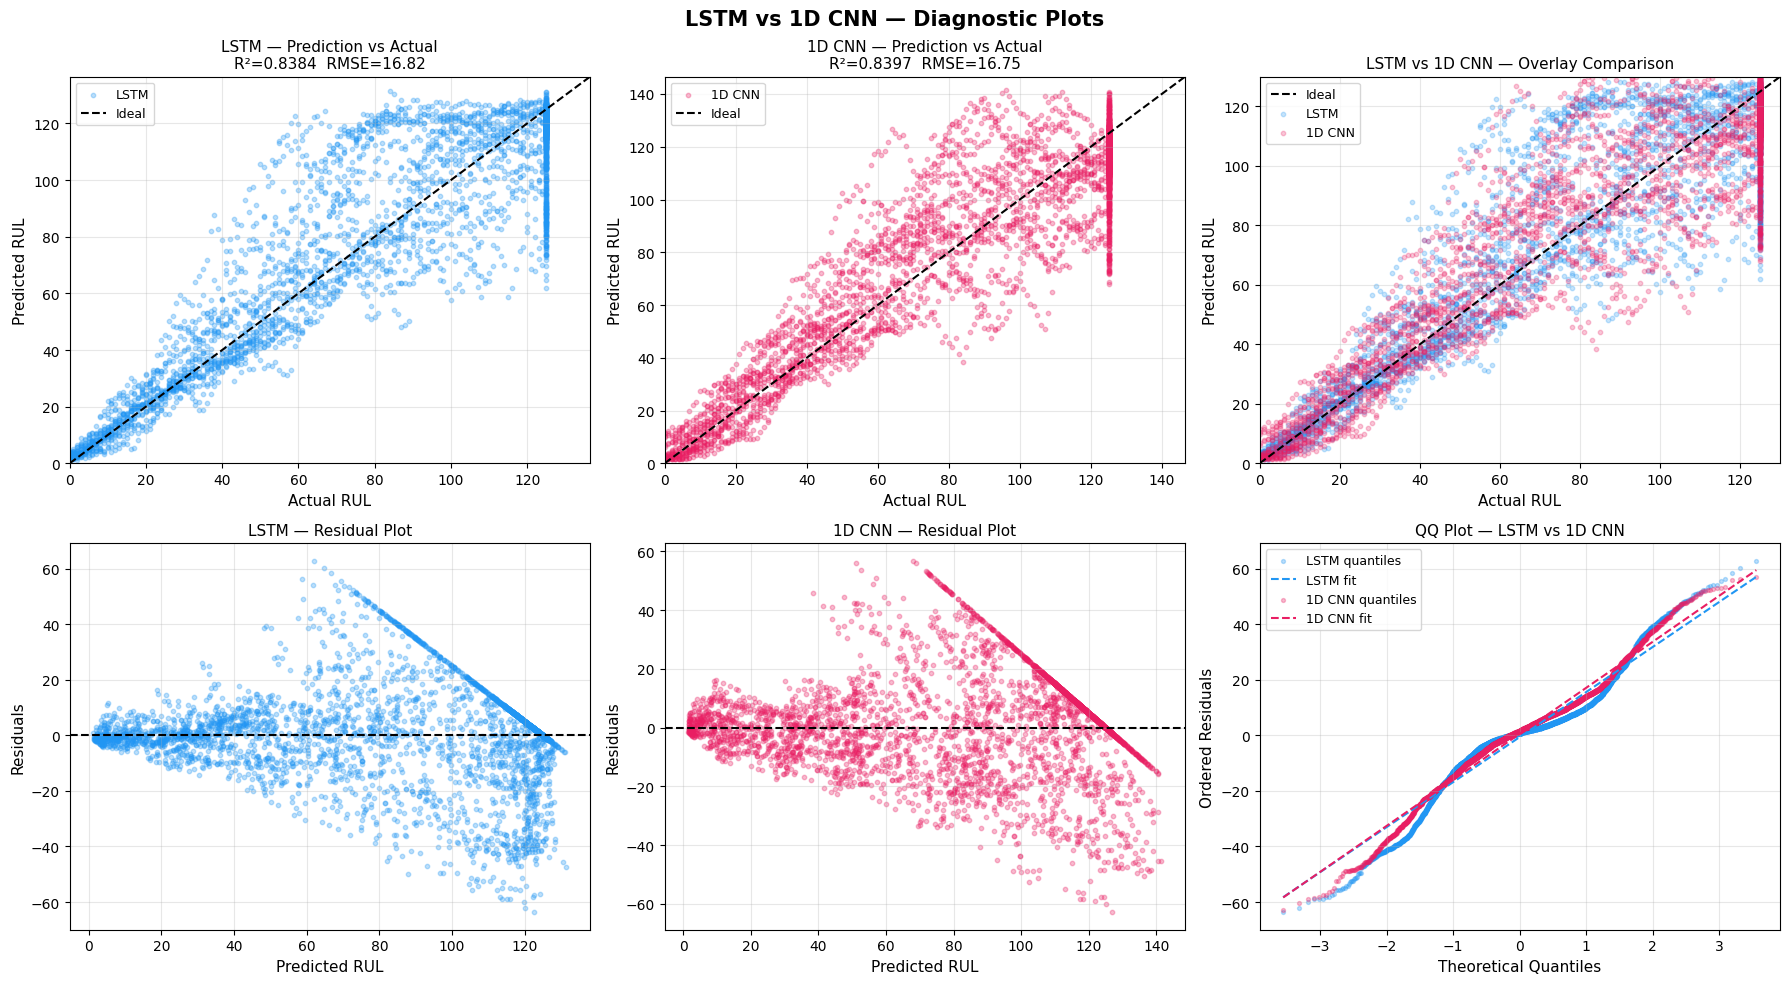

In [36]:
import scipy.stats as stats

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LSTM vs 1D CNN — Diagnostic Plots", fontsize=15, fontweight='bold')

y_true   = y_test_seq
preds    = {'LSTM': y_pred_lstm, '1D CNN': y_pred_cnn}
colors   = {'LSTM': '#2196F3',   '1D CNN': '#E91E63'}

for col, (model_name, y_pred) in enumerate(preds.items()):
    color    = colors[model_name]
    residuals = y_true - y_pred
    r2        = r2_score(y_true, y_pred)
    rmse      = np.sqrt(mean_squared_error(y_true, y_pred))

    # ── Row 0: Prediction vs Actual ──────────────────────────
    ax = axes[0, col]
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color=color, label=model_name)
    lims = [0, max(y_true.max(), y_pred.max()) + 5]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Ideal')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual RUL',    fontsize=11)
    ax.set_ylabel('Predicted RUL', fontsize=11)
    ax.set_title(f'{model_name} — Prediction vs Actual\nR²={r2:.4f}  RMSE={rmse:.2f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # ── Row 1: Residual Plot ──────────────────────────────────
    ax = axes[1, col]
    ax.scatter(y_pred, residuals, alpha=0.3, s=10, color=color)
    ax.axhline(0, color='black', linestyle='--', lw=1.5)
    ax.set_xlabel('Predicted RUL', fontsize=11)
    ax.set_ylabel('Residuals',     fontsize=11)
    ax.set_title(f'{model_name} — Residual Plot', fontsize=11)
    ax.grid(alpha=0.3)

# ── Row 0 col 2: Overlaid Prediction vs Actual ───────────────
ax = axes[0, 2]
lims = [0, y_true.max() + 5]
ax.plot(lims, lims, 'k--', lw=1.5, label='Ideal', zorder=3)
for model_name, y_pred in preds.items():
    ax.scatter(y_true, y_pred, alpha=0.25, s=10,
               color=colors[model_name], label=model_name)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual RUL',    fontsize=11)
ax.set_ylabel('Predicted RUL', fontsize=11)
ax.set_title('LSTM vs 1D CNN — Overlay Comparison', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Row 1 col 2: QQ plots side by side ───────────────────────
ax = axes[1, 2]
for model_name, y_pred in preds.items():
    residuals = y_true - y_pred
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=8, color=colors[model_name], label=f'{model_name} quantiles')
    ax.plot(osm, slope * np.array(osm) + intercept,
            color=colors[model_name], lw=1.5, linestyle='--', label=f'{model_name} fit')
ax.set_xlabel('Theoretical Quantiles', fontsize=11)
ax.set_ylabel('Ordered Residuals',     fontsize=11)
ax.set_title('QQ Plot — LSTM vs 1D CNN', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/lstm_cnn_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

### All Model Comparison
Final Comparison of R2 of all 5 models train on dataset FD001 

In [37]:
results = pd.DataFrame({
    'Model': ['1D CNN', 'LSTM'],
    'R2' : [
        r2_score(y_test_seq, y_pred_cnn),
        r2_score(y_test_seq, y_pred_lstm),
    ],
})

print(results)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Neural Network'],
    'R2_baseline' : [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_nn)
    ],
    'R2_tuned': [
        r2_score(y_test, y_pred_lr_tuned),
        r2_score(y_test, y_pred_rf_tuned),
        r2_score(y_test, y_pred_nn_tuned)
    ]
})

print(results)

    Model        R2
0  1D CNN  0.839684
1    LSTM  0.838396
               Model  R2_baseline  R2_tuned
0  Linear Regression     0.803480  0.831801
1      Random Forest     0.842333  0.868517
2     Neural Network     0.836965  0.844105


### Why do LSTM and 1D CNN underperform tabular models on this dataset?

- On FD001, well-regularised tabular models with strong feature engineering can match or outperform sequential models as FD001 has a single operating condition and single fault mode, so degradation is smooth and near-linear after RUL clipping
- Engineered features (rolling mean, lag, cumulative degradation) already capture most temporal structure  
- Little remaining sequential signal for LSTM or 1D CNN to learn beyond tabular inputs  
- Sliding window (SEQ_LEN = 20) removes early cycles, reducing effective training data for sequence models  
- Dataset is relatively small (~100 engines), making this reduction more impactful  
- Results align with CMAPSS findings: sequence models perform better on FD003 and FD004 with multiple conditions and fault modes  

Key takeaway: model complexity should match data complexity  